# Preprocessing Data / Feature Engineering:
## Loading Data

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno

In [2]:
df = pd.read_csv('financial_regression.csv')
df.head()

,date,sp500 open,sp500 high,sp500 low,sp500 close,sp500 volume,sp500 high-low,nasdaq open,nasdaq high,nasdaq low,...,palladium high,palladium low,palladium close,palladium volume,palladium high-low,gold open,gold high,gold low,gold close,gold volume
0,2010-01-14,114.49,115.14,114.42,114.93,115646960.0,0.72,46.26,46.520,46.22,...,45.02,43.86,44.84,364528.0,1.16,111.51,112.37,110.79,112.03,18305238.0
1,2010-01-15,114.73,114.84,113.20,113.64,212252769.0,1.64,46.46,46.550,45.65,...,45.76,44.40,45.76,442210.0,1.36,111.35,112.01,110.38,110.86,18000724.0
2,2010-01-18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-19,113.62,115.13,113.59,115.06,138671890.0,1.54,45.96,46.640,45.95,...,47.08,45.70,46.94,629150.0,1.38,110.95,111.75,110.83,111.52,10467927.0
4,2010-01-20,114.28,114.45,112.98,113.89,216330645.0,1.47,46.27,46.604,45.43,...,47.31,45.17,47.05,643198.0,2.14,109.97,110.05,108.46,108.94,17534231.0


In [3]:
df.shape

(3904, 47)

In [5]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3904 entries, 0 to 3903
Data columns (total 47 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                3904 non-null   object 
 1   sp500 open          3719 non-null   float64
 2   sp500 high          3719 non-null   float64
 3   sp500 low           3719 non-null   float64
 4   sp500 close         3719 non-null   float64
 5   sp500 volume        3719 non-null   float64
 6   sp500 high-low      3719 non-null   float64
 7   nasdaq open         3719 non-null   float64
 8   nasdaq high         3719 non-null   float64
 9   nasdaq low          3719 non-null   float64
 10  nasdaq close        3719 non-null   float64
 11  nasdaq volume       3719 non-null   float64
 12  nasdaq high-low     3719 non-null   float64
 13  us_rates_%          176 non-null    float64
 14  CPI                 176 non-null    float64
 15  usd_chf             3694 non-null   float64
 16  eur_us

In [24]:
print(df.columns)

Index(['date', 'sp500 open', 'sp500 high', 'sp500 low', 'sp500 close',
       'sp500 volume', 'sp500 high-low', 'nasdaq open', 'nasdaq high',
       'nasdaq low', 'nasdaq close', 'nasdaq volume', 'nasdaq high-low',
       'us_rates_%', 'CPI', 'usd_chf', 'eur_usd', 'GDP', 'silver open',
       'silver high', 'silver low', 'silver close', 'silver volume',
       'silver high-low', 'oil open', 'oil high', 'oil low', 'oil close',
       'oil volume', 'oil high-low', 'platinum open', 'platinum high',
       'platinum low', 'platinum close', 'platinum volume',
       'platinum high-low', 'palladium open', 'palladium high',
       'palladium low', 'palladium close', 'palladium volume',
       'palladium high-low', 'gold open', 'gold high', 'gold low',
       'gold close', 'gold volume', 'DayOfWeek', 'Month', 'Quarter',
       'DayOfYear', 'IsMonthEnd', 'Target_Next_Close', 'Close_Lag1',
       'Open_Lag1', 'Daily_Return'],
      dtype='object')


In [20]:
print("Percentage of Missing Values (Before Feature Engineering) :")
(df.isnull().sum()/len(df))*100

Percentage of Missing Values (Before Feature Engineering) :


date                   0.000000
sp500 open             4.738730
sp500 high             4.738730
sp500 low              4.738730
sp500 close            4.738730
sp500 volume           4.738730
sp500 high-low         4.738730
nasdaq open            4.738730
nasdaq high            4.738730
nasdaq low             4.738730
nasdaq close           4.738730
nasdaq volume          4.738730
nasdaq high-low        4.738730
us_rates_%            95.491803
CPI                   95.491803
usd_chf                5.379098
eur_usd                5.379098
GDP                   98.539959
silver open            4.738730
silver high            4.738730
silver low             4.738730
silver close           4.738730
silver volume          4.738730
silver high-low        4.738730
oil open               4.738730
oil high               4.738730
oil low                4.738730
oil close              4.738730
oil volume             4.738730
oil high-low           4.738730
platinum open          4.738730
platinum

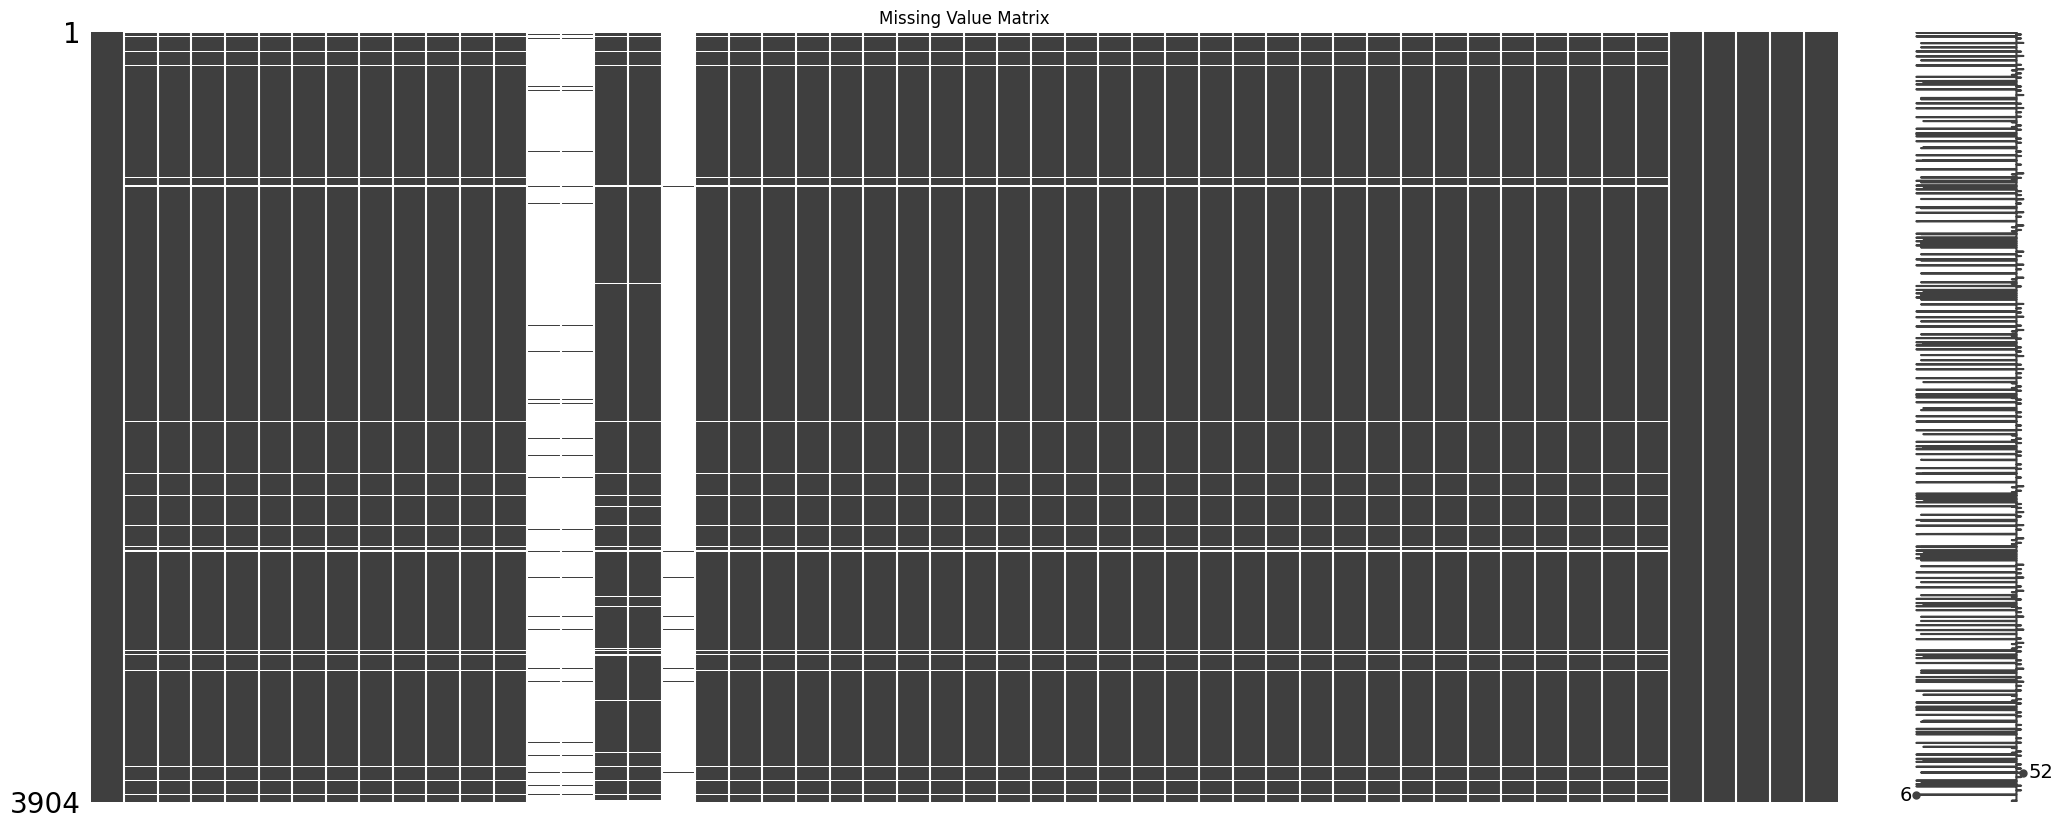

In [10]:
msno.matrix(df)
plt.title("Missing Value Matrix")
plt.show()

In [ ]:
# We must standardize the dates in our data in order for our model to understand that markets close on Friday and re-open on Monday.

# Convert to datetime
df["date"] = pd.to_datetime(df["date"])

# Extract calendar components
df["DayOfWeek"] = df["date"].dt.dayofweek  # 0 = Monday, 4 = Friday
df["Month"] = df["date"].dt.month
df["Quarter"] = df["date"].dt.quarter
df["DayOfYear"] = df["date"].dt.dayofyear
df["IsMonthEnd"] = df["date"].dt.is_month_end.astype(int)

In [ ]:
# In regards to our linear regression model, we want to predict the future price of gold. In this data set we are split up by the 
# days of the week the stock market is open so we must take this into consideration when we split the model. Here we append the future closing
# price of gold for a given observation as it must serve as our target variable. We also compute the daily return from the difference of the 
# gold open and gold closing price. 

# Create the target: shifted by -1 day (Tomorrow's Close)
df["Target_Next_Close"] = df["gold close"].shift(-1)

# Create lagged features (Yesterday's values)
df["Close_Lag1"] = df["gold close"].shift(1)
df["Open_Lag1"] = df["gold open"].shift(1)

# Daily Return feature (Today's Open to Close spread)
df["Daily_Return"] = (df["gold close"] - df["gold open"]) / df["gold open"]

df[["gold open","gold close","Target_Next_Close","Close_Lag1","Open_Lag1","Daily_Return"]]

,gold open,gold close,Target_Next_Close,Close_Lag1,Open_Lag1,Daily_Return
0,111.51,112.03,110.86,NaN,NaN,0.004663
1,111.35,110.86,NaN,112.03,111.51,-0.004401
2,NaN,NaN,111.52,110.86,111.35,NaN
3,110.95,111.52,108.94,NaN,NaN,0.005137
4,109.97,108.94,107.37,111.52,110.95,-0.009366
...,...,...,...,...,...,...
3899,247.75,248.63,251.27,247.15,247.62,0.003552
3900,250.00,251.27,251.22,248.63,247.75,0.005080
3901,252.74,251.22,253.93,251.27,250.00,-0.006014
3902,253.06,253.93,250.87,251.22,252.74,0.003438


In [21]:
df.shape

(3904, 56)

In [22]:
print("Percentage of Missing Values (After Feature Engineering) :")
(df.isnull().sum()/len(df))*100

Percentage of Missing Values (After Feature Engineering) :


date                   0.000000
sp500 open             4.738730
sp500 high             4.738730
sp500 low              4.738730
sp500 close            4.738730
sp500 volume           4.738730
sp500 high-low         4.738730
nasdaq open            4.738730
nasdaq high            4.738730
nasdaq low             4.738730
nasdaq close           4.738730
nasdaq volume          4.738730
nasdaq high-low        4.738730
us_rates_%            95.491803
CPI                   95.491803
usd_chf                5.379098
eur_usd                5.379098
GDP                   98.539959
silver open            4.738730
silver high            4.738730
silver low             4.738730
silver close           4.738730
silver volume          4.738730
silver high-low        4.738730
oil open               4.738730
oil high               4.738730
oil low                4.738730
oil close              4.738730
oil volume             4.738730
oil high-low           4.738730
platinum open          4.738730
platinum

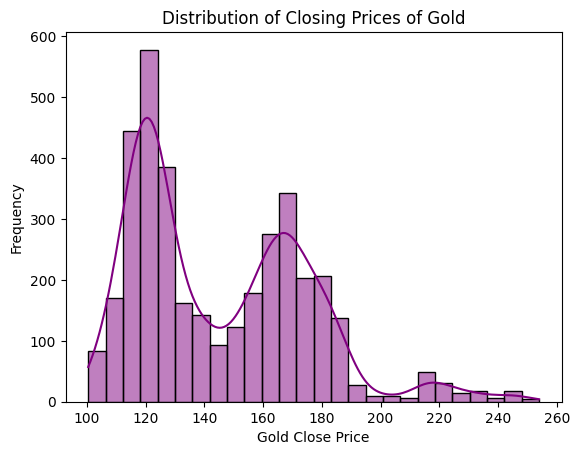

In [18]:
sns.histplot(df["Target_Next_Close"],color = 'purple',kde = True)
plt.title("Distribution of Closing Prices of Gold")
plt.xlabel("Gold Close Price")
plt.ylabel("Frequency")
plt.show()

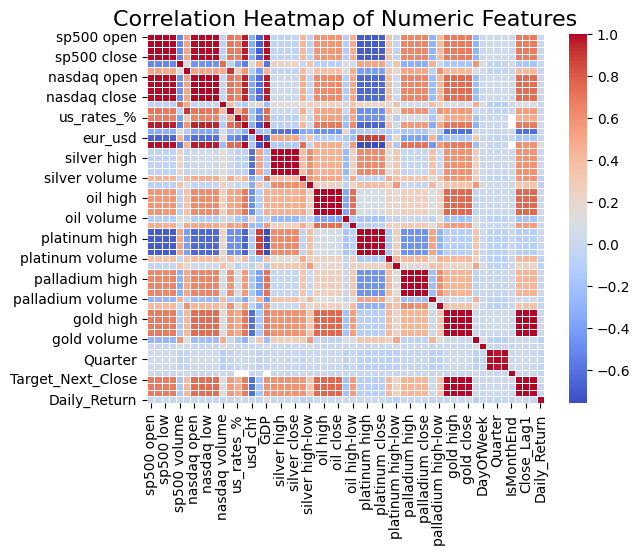

In [28]:
df_numeric = df.select_dtypes(include=[np.number])

sns.heatmap(df_numeric.corr(), cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontsize=16)
plt.show()